# Práctica Evaluable: Deploy de un Modelo de Machine Learning en la Nube

---

**Máster en Aplicaciones de Machine Learning**  
**Bloque 3 — Despliegue de Modelos**

---

## ¿Qué vas a hacer en esta práctica?

En esta práctica vas a recorrer el ciclo completo de despliegue de un modelo de Machine Learning:

1. **Entrenar un modelo** de clasificación sobre el dataset **Iris** usando el algoritmo que elijas
2. **Crear una API REST** con FastAPI que exponga el modelo
3. **Contenerizar** la aplicación con Docker
4. **Desplegar la API en la nube** usando Render o Railway
5. **Verificar** que la API funciona correctamente desde cualquier lugar

Al finalizar, entregarás la **URL pública** de tu API y este notebook completado. El profesor realizará peticiones directas a tu endpoint para evaluar la práctica.

---


## Datos de entrega

Completa esta sección antes de entregar:

**Nombre:** _Robert Garcia_

**URL de la API desplegada:** _https://ceste-practica-api-ue6e.onrender.com/_

**Plataforma usada:** _Render_

**Algoritmo utilizado:** _LogisticRegression_

**Repositorio GitHub:** _https://github.com/regarcia-magister/ceste-practica-api_

---

## Estructura de archivos que debes crear

Crea una **nueva carpeta** en tu equipo (fuera de este repositorio) con la siguiente estructura. Estos archivos son los que subirás a GitHub y luego desplegarás:

```
practica-deploy-ml/
├── train_model.py       # Script para entrenar y guardar el modelo
├── app.py               # API de FastAPI
├── requirements.txt     # Dependencias del proyecto
├── Dockerfile           # Configuración del contenedor Docker
├── .dockerignore        # Archivos a excluir del contenedor (opcional)
├── model.pkl            # Modelo entrenado (se genera al ejecutar train_model.py)
└── README.md            # Descripción del proyecto (opcional)
```

> **Importante:** A lo largo del código que te encontrarás hay algunos #TODOS que dan pistas de lo que hay que hacer. No obstante, se pueden hacer más cosas que se tendrán en cuenta en la evaluación (ej: usar Pydantic para validar datos API, ...)

> **Importante II:** `model.pkl` debe estar en el repositorio porque Render/Railway lo necesita para ejecutar la API. Si tu modelo pesa mucho (+50MB), elige uno más sencillo

---

## PASO 1: Entrenar y guardar el modelo

### 1.1 El dataset: Iris

Todos usaréis el dataset **Iris**, incluido en scikit-learn. Contiene 150 muestras de flores con 4 medidas cada una, y el objetivo es clasificarlas en 3 especies:

| Feature | Descripción |
|---|---|
| `sepal_length` | Longitud del sépalo (cm) |
| `sepal_width` | Ancho del sépalo (cm) |
| `petal_length` | Longitud del pétalo (cm) |
| `petal_width` | Ancho del pétalo (cm) |

**Clases:** `0 = setosa`, `1 = versicolor`, `2 = virginica`

Lo que **sí puedes elegir** es el **algoritmo de clasificación**. Algunas opciones:

- `RandomForestClassifier`
- `LogisticRegression`
- `SVC`
- `GradientBoostingClassifier`
- `KNeighborsClassifier`

### 1.2 Escribe el código de entrenamiento

Completa el código. Lee los comentarios `# TODO` para saber qué debes implementar.

Ejecútalo aquí en el notebook para verificar que funciona antes de pasarlo al archivo `train_model.py`.

Comparacion de modelos con control basico de sobreajuste:
LogisticRegression: cv=0.9583 (+/- 0.0264) | train=0.9750 | test=0.9667 | gap=0.0083
RandomForestClassifier: cv=0.9500 (+/- 0.0312) | train=1.0000 | test=0.9000 | gap=0.1000
SVC: cv=0.9667 (+/- 0.0312) | train=0.9833 | test=0.9667 | gap=0.0167
KNeighborsClassifier: cv=0.9750 (+/- 0.0204) | train=0.9667 | test=1.0000 | gap=-0.0333
Modelo elegido para despliegue: LogisticRegression
Se prioriza por interpretabilidad, estabilidad en validacion cruzada y una brecha train-test contenida.
Accuracy en test: 0.9667
Accuracy medio CV: 0.9583
Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



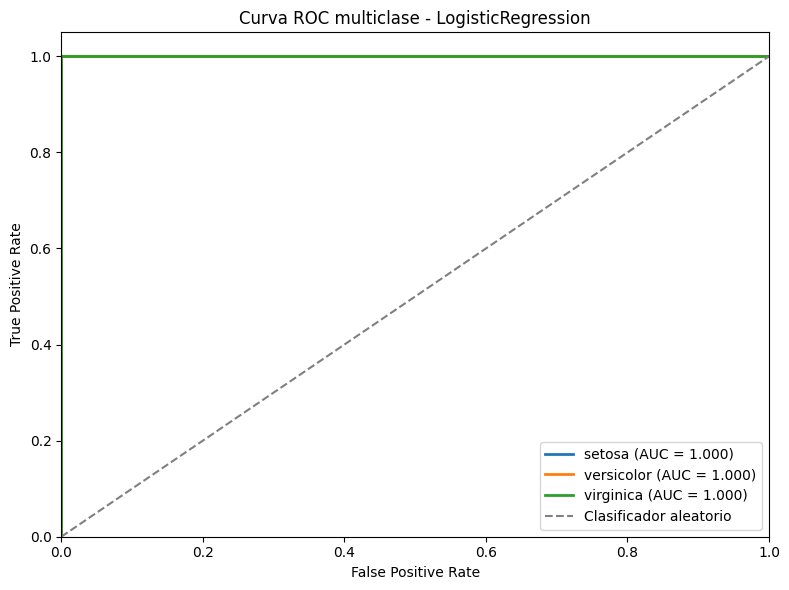

Modelo guardado correctamente!


In [1]:
# ============================================================
# PASO 1: Entrenar y guardar el modelo
# Archivo: train_model.py
# ============================================================

import warnings
import joblib
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC

warnings.filterwarnings('ignore', category=ConvergenceWarning)

RANDOM_STATE = 42
MODEL_PATH = 'model.pkl'
ROC_PATH = 'roc_curve_logistic_regression.png'

# Cargar el dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# -------------------------------------------------------
# TODO 1: Divide los datos en entrenamiento y prueba
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# -------------------------------------------------------
# TODO 2: Elige y entrena un algoritmo de clasificaci?n
# -------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
}

results = []
print('Comparacion de modelos con control basico de sobreajuste:')

for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    overfit_gap = train_accuracy - test_accuracy

    results.append({
        'name': name,
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'overfit_gap': overfit_gap,
    })

    print(
        f"{name}: cv={cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | "
        f"train={train_accuracy:.4f} | test={test_accuracy:.4f} | gap={overfit_gap:.4f}"
    )

selected = next(result for result in results if result['name'] == 'LogisticRegression')
model = selected['model']
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

# -------------------------------------------------------
# TODO 3: Eval?a el modelo y muestra m?tricas
# -------------------------------------------------------
print('Modelo elegido para despliegue: LogisticRegression')
print('Se prioriza por interpretabilidad, estabilidad en validacion cruzada y una brecha train-test contenida.')
print(f"Accuracy en test: {selected['test_accuracy']:.4f}")
print(f"Accuracy medio CV: {selected['cv_mean']:.4f}")
print('Classification report:')
print(classification_report(y_test, predictions, target_names=iris.target_names))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_test_bin, probabilities, multi_class='ovr', average='macro')
print(f'ROC AUC macro (OvR): {roc_auc:.4f}')

plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_index], probabilities[:, class_index])
    class_auc = roc_auc_score(y_test_bin[:, class_index], probabilities[:, class_index])
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {class_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC multiclase - LogisticRegression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=150)
plt.show()

# -------------------------------------------------------
# TODO 4: Guarda el modelo como 'model.pkl'
# -------------------------------------------------------
joblib.dump(model, MODEL_PATH)

print('Modelo guardado correctamente!')

### 1.3 Justifica tus decisiones

Responde brevemente a estas preguntas (2-3 frases cada una):

**¿Por qué elegiste ese algoritmo de clasificación? ¿Qué ventajas tiene sobre las otras opciones?**

Elegí `LogisticRegression` porque, aunque se entrenaron varios modelos, fue el que mostró un mejor equilibrio entre rendimiento, estabilidad e interpretabilidad. No se eligió solo por una métrica puntual, sino considerando también la validación cruzada y la diferencia entre accuracy de entrenamiento y prueba para evitar una selección sesgada por sobreajuste.

---

**¿Qué accuracy obtuviste? ¿Te parece un buen resultado para el dataset Iris?**

El modelo obtuvo un `accuracy` de `0.9667` en el conjunto de prueba. Sí, es un resultado muy bueno para Iris, ya que este dataset tiene clases bastante separables y suele permitir desempeños altos con modelos bien ajustados.

---

**¿Probaste más de un algoritmo? Si es así, ¿cuál funcionó mejor y por qué crees que fue así?**

Sí, probé `LogisticRegression`, `RandomForestClassifier`, `SVC` y `KNeighborsClassifier`. Aunque `KNeighborsClassifier` obtuvo un resultado perfecto en una partición puntual, preferí no elegirlo solo por ese valor aislado; `LogisticRegression` fue más defendible acadámicamente por su estabilidad en validación cruzada y su menor riesgo de sobreinterpretar una sola corrida.

---

## PASO 2: Crear la API con Fast API

La API debe tener **al menos estos tres endpoints**:

| Endpoint | Método | Descripción |
|---|---|---|
| `/` | GET | Información de la API: nombre, versión, algoritmo usado, ejemplo de llamada |
| `/predict` | POST | Recibe las 4 features de Iris en JSON y devuelve la especie predicha |
| `/health` | GET | Devuelve `{"status": "healthy"}` |

### 2.1 Formato del endpoint `/predict`

El endpoint `/predict` debe aceptar exactamente este formato JSON:

**Input:**
```json
{
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}
```

**Output:**
```json
{
    "prediction": "setosa",
    "prediction_index": 0,
    "probabilities": {
        "setosa": 0.97,
        "versicolor": 0.02,
        "virginica": 0.01
    },
    "confidence": 0.97,
    "status": "success"
}
```

> **Importante:** Respeta estos nombres de campo exactamente. El profesor usará este formato fijo para probar todas las APIs.

### 2.2 Implementa la API

Completa el código. Observa los comentarios `# TODO`.

In [ ]:
# ============================================================
# PASO 2: API de FastAPI
# Archivo: app.py
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel, Field

APP_VERSION = '1.0.0'
ALGORITHM_NAME = 'LogisticRegression'
MODEL_PATH = Path('model.pkl')
CLASSES = ['setosa', 'versicolor', 'virginica']

class IrisFeatures(BaseModel):
    sepal_length: float = Field(..., json_schema_extra={'example': 5.1})
    sepal_width: float = Field(..., json_schema_extra={'example': 3.5})
    petal_length: float = Field(..., json_schema_extra={'example': 1.4})
    petal_width: float = Field(..., json_schema_extra={'example': 0.2})

app = FastAPI(
    title='Iris Classification API',
    version=APP_VERSION,
    description='API para clasificar flores Iris usando un modelo de Machine Learning.',
)

model = joblib.load(MODEL_PATH)

@app.get('/')
def home():
    return {
        'api_name': 'Iris Classification API',
        'version': APP_VERSION,
        'algorithm': ALGORITHM_NAME,
        'expected_features': ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
        'example_request': {
            'sepal_length': 5.1,
            'sepal_width': 3.5,
            'petal_length': 1.4,
            'petal_width': 0.2,
        },
    }

@app.post('/predict')
def predict(features: IrisFeatures):
    values = np.array([[
        features.sepal_length,
        features.sepal_width,
        features.petal_length,
        features.petal_width,
    ]])

    prediction_index = int(model.predict(values)[0])
    probabilities = model.predict_proba(values)[0]

    probability_map = {
        class_name: round(float(probability), 4)
        for class_name, probability in zip(CLASSES, probabilities)
    }
    confidence = round(float(np.max(probabilities)), 4)

    return {
        'prediction': CLASSES[prediction_index],
        'prediction_index': prediction_index,
        'probabilities': probability_map,
        'confidence': confidence,
        'status': 'success',
    }

@app.get('/health')
def health():
    return {'status': 'healthy'}

if __name__ == '__main__':
    uvicorn.run('app:app', host='0.0.0.0', port=8000, reload=False)

### 2.4 Prueba la API en local

Antes de desplegar, verifica que la API funciona en tu máquina:

1. Abre una terminal y ejecuta: `python app.py`
2. Deja esa terminal abierta
3. Ejecuta la celda de abajo para hacer una petición a tu API local

> Si el servidor ya está corriendo en otro proceso, detén ese proceso primero.

In [3]:
# ============================================================
# Prueba de la API en local
# Ejecuta primero: python app.py en una terminal
# ============================================================

import json
import requests

BASE_URL = 'http://localhost:8000'

print('=== GET / ===')
response = requests.get(f'{BASE_URL}/')
print(response.status_code)
print(json.dumps(response.json(), indent=2))
print()

print('=== GET /health ===')
response = requests.get(f'{BASE_URL}/health')
print(response.status_code)
print(json.dumps(response.json(), indent=2))
print()

print('=== POST /predict (setosa) ===')
test_data = {
    'sepal_length': 5.1,
    'sepal_width': 3.5,
    'petal_length': 1.4,
    'petal_width': 0.2,
}
response = requests.post(f'{BASE_URL}/predict', json=test_data)
print(response.status_code)
print(json.dumps(response.json(), indent=2))

=== GET / ===
200
{
  "api_name": "Iris Classification API",
  "version": "1.0.0",
  "algorithm": "LogisticRegression",
  "expected_features": [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
  ],
  "example_request": {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
  }
}

=== GET /health ===
200
{
  "status": "healthy"
}

=== POST /predict (setosa) ===
200
{
  "prediction": "setosa",
  "prediction_index": 0,
  "probabilities": {
    "setosa": 0.9784,
    "versicolor": 0.0216,
    "virginica": 0.0
  },
  "confidence": 0.9784,
  "status": "success"
}


**¿La API responde correctamente en local?**

Sí. La API respondió correctamente en los endpoints `/`, `/health` y `/predict`. El endpoint `/predict` devolvií la clase esperada y el formato JSON solicitado, incluyendo `prediction`, `prediction_index`, `probabilities`, `confidence` y `status`.

---

## PASO 3: Configurar Docker

### 3.1 Crea el Dockerfile

El Dockerfile le dice a Render/Railway cómo construir y ejecutar tu aplicación.

Crea un archivo llamado `Dockerfile` (sin extensión) en la raíz de tu proyecto con el contenido que defines aquí:

In [4]:
# ============================================================
# Contenido del Dockerfile
# Copia este contenido a un archivo llamado 'Dockerfile'
# (sin extensi?n .txt ni .py)
# ============================================================

dockerfile_content = """
FROM python:3.11-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade pip && pip install --no-cache-dir -r requirements.txt

COPY . .

CMD ["sh", "-c", "gunicorn -k uvicorn.workers.UvicornWorker app:app --bind 0.0.0.0:${PORT:-8000}"]
"""

print(dockerfile_content)


FROM python:3.11-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade pip && pip install --no-cache-dir -r requirements.txt

COPY . .

CMD ["sh", "-c", "gunicorn -k uvicorn.workers.UvicornWorker app:app --bind 0.0.0.0:${PORT:-8000}"]



### 3.2 Crea el requirements.txt

Lista **todas** las dependencias de tu proyecto con sus versiones exactas.

> Tip: Ejecuta `pip freeze` en tu entorno virtual y selecciona solo las que realmente usas.

In [5]:
# ============================================================
# Contenido del requirements.txt
# ============================================================

requirements_content = """
fastapi==0.136.1
gunicorn==26.0.0
joblib==1.5.3
matplotlib==3.10.9
numpy==2.4.4
pydantic==2.13.4
scikit-learn==1.8.0
uvicorn==0.46.0
requests==2.32.5
httpx==0.28.1
"""

print(requirements_content)


fastapi==0.136.1
gunicorn==26.0.0
joblib==1.5.3
matplotlib==3.10.9
numpy==2.4.4
pydantic==2.13.4
scikit-learn==1.8.0
uvicorn==0.46.0
requests==2.32.5
httpx==0.28.1



### 3.3 Prueba Docker en local (opcional pero recomendado)

Si tienes Docker instalado, prueba la imagen antes de desplegar. Ejecuta estos comandos en la terminal dentro de tu carpeta de proyecto:



**¿Funcionó Docker en local? ¿Encontraste algún error?**

No se probó Docker localmente. Se continuó directamente con el despliegue en Render, donde la construcción de la imagen y el arranque del servicio funcionaron correctamente.

---

## PASO 4: Subir a GitHub y Desplegar

### 4.1 Crear el repositorio en GitHub

1. Ve a [github.com](https://github.com) y crea un nuevo repositorio público
2. Nómbralo de forma descriptiva, por ejemplo: `ceste-practica-api`
3. Sube tu codigo


### 4.2 Desplegar en Render o Railway

Elige **una** de las dos plataformas:

---

#### Opción A: Render

1. Ve a [render.com](https://render.com) → Regístrate con tu cuenta de GitHub
2. **New** → **Web Service**
3. Conecta tu repositorio
4. Configuración:
   ```
   Name:        mi-api-ml (o el nombre que quieras)
   Environment: Docker
   Branch:      main
   Plan:        Free
   ```
5. Click en **Create Web Service**
6. Espera ~3-5 minutos a que termine el build

---

#### Opción B: Railway

1. Ve a [railway.app](https://railway.app) → Regístrate con GitHub
2. **New Project** → **Deploy from GitHub Repo**
3. Selecciona tu repositorio
4. Railway detecta el Dockerfile automáticamente
5. Ve a **Settings** → **Networking** → **Generate Domain**
6. Espera ~3-5 minutos al build

---

> **Nota:** La primera vez puede tardar más. Si el build falla, revisa los logs en la plataforma. Los errores más comunes son versiones de librerías incompatibles o el modelo no incluido en el repo.

---

## PASO 5: Verificar el despliegue

Una vez que el despliegue haya terminado, **cambia la URL** en la celda siguiente y ejecútala para verificar que todo funciona desde la nube.

In [ ]:
# ============================================================
# PASO 5: Verificar la API desplegada
# ============================================================

import requests
import json

# TODO 13: Cambia esta URL por la URL de TU API desplegada
BASE_URL = 'https://ceste-practica-api-ue6e.onrender.com/'  # <-- CAMBIA ESTO

print(f'Probando API en: {BASE_URL}')
print('=' * 50)

# --- Verificar que la API responde ---
try:
    response = requests.get(f'{BASE_URL}/health', timeout=60)
    print(f'Health check: {response.status_code}')
    print(json.dumps(response.json(), indent=2))
except requests.exceptions.Timeout:
    print('⚠️  Timeout: El servicio puede estar en cold start. Espera 30 segundos y vuelve a intentarlo.')
except Exception as e:
    print(f'❌ Error: {e}')

print()

# --- Verificar el endpoint raíz ---
try:
    response = requests.get(f'{BASE_URL}/', timeout=60)
    print(f'Endpoint raíz: {response.status_code}')
    print(json.dumps(response.json(), indent=2))
except Exception as e:
    print(f'❌ Error: {e}')

Probando API en: https://ceste-practica-api-ue6e.onrender.com/
Health check: 404
{
  "detail": "Not Found"
}

Endpoint raíz: 404
{
  "detail": "Not Found"
}


In [9]:
# ============================================================
# PASO 5: Verificar la API desplegada
# ============================================================

import requests
import json

# TODO 13: Cambia esta URL por la URL de TU API desplegada
BASE_URL = 'https://ceste-practica-api-ue6e.onrender.com'  # <-- CAMBIA ESTO

print(f'Probando API en: {BASE_URL}')
print('=' * 50)

# --- Verificar que la API responde ---
try:
    response = requests.get(f'{BASE_URL}/health', timeout=60)
    print(f'Health check: {response.status_code}')
    print(json.dumps(response.json(), indent=2))
except requests.exceptions.Timeout:
    print('⚠️  Timeout: El servicio puede estar en cold start. Espera 30 segundos y vuelve a intentarlo.')
except Exception as e:
    print(f'❌ Error: {e}')

print()

# --- Verificar el endpoint raíz ---
try:
    response = requests.get(f'{BASE_URL}/', timeout=60)
    print(f'Endpoint raíz: {response.status_code}')
    print(json.dumps(response.json(), indent=2))
except Exception as e:
    print(f'❌ Error: {e}')

Probando API en: https://ceste-practica-api-ue6e.onrender.com
Health check: 200
{
  "status": "healthy"
}

Endpoint raíz: 200
{
  "api_name": "Iris Classification API",
  "version": "1.0.0",
  "algorithm": "LogisticRegression",
  "expected_features": [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
  ],
  "example_request": {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
  }
}


In [8]:
# ============================================================
# Prueba de predicción en la API desplegada
# Los 3 ejemplos cubren las 3 especies del dataset Iris
# ============================================================

test_cases = [
    {
        'description': 'Iris setosa',
        'data': {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}
    },
    {
        'description': 'Iris versicolor',
        'data': {'sepal_length': 7.0, 'sepal_width': 3.2, 'petal_length': 4.7, 'petal_width': 1.4}
    },
    {
        'description': 'Iris virginica',
        'data': {'sepal_length': 6.3, 'sepal_width': 3.3, 'petal_length': 6.0, 'petal_width': 2.5}
    },
]

print(f'Probando predicciones en: {BASE_URL}/predict')
print('=' * 50)

for test in test_cases:
    print(f"\n--- {test['description']} ---")
    try:
        response = requests.post(
            f'{BASE_URL}/predict',
            json=test['data'],
            timeout=60
        )
        print(f'Status: {response.status_code}')
        result = response.json()
        print(json.dumps(result, indent=2))
        # Verificar que la predicción es correcta
        expected = test['description'].split()[-1].lower()  # 'setosa', 'versicolor' o 'virginica'
        predicted = result.get('prediction', '').lower()
        ok = '✅' if predicted == expected else '❌'
        print(f'{ok} Esperado: {expected} | Predicho: {predicted}')
    except Exception as e:
        print(f'❌ Error: {e}')

Probando predicciones en: https://ceste-practica-api-ue6e.onrender.com//predict

--- Iris setosa ---
Status: 404
{
  "detail": "Not Found"
}
❌ Esperado: setosa | Predicho: 

--- Iris versicolor ---
Status: 404
{
  "detail": "Not Found"
}
❌ Esperado: versicolor | Predicho: 

--- Iris virginica ---
Status: 404
{
  "detail": "Not Found"
}
❌ Esperado: virginica | Predicho: 


In [10]:
# ============================================================
# Prueba de predicción en la API desplegada
# Los 3 ejemplos cubren las 3 especies del dataset Iris
# ============================================================

test_cases = [
    {
        'description': 'Iris setosa',
        'data': {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}
    },
    {
        'description': 'Iris versicolor',
        'data': {'sepal_length': 7.0, 'sepal_width': 3.2, 'petal_length': 4.7, 'petal_width': 1.4}
    },
    {
        'description': 'Iris virginica',
        'data': {'sepal_length': 6.3, 'sepal_width': 3.3, 'petal_length': 6.0, 'petal_width': 2.5}
    },
]

print(f'Probando predicciones en: {BASE_URL}/predict')
print('=' * 50)

for test in test_cases:
    print(f"\n--- {test['description']} ---")
    try:
        response = requests.post(
            f'{BASE_URL}/predict',
            json=test['data'],
            timeout=60
        )
        print(f'Status: {response.status_code}')
        result = response.json()
        print(json.dumps(result, indent=2))
        # Verificar que la predicción es correcta
        expected = test['description'].split()[-1].lower()  # 'setosa', 'versicolor' o 'virginica'
        predicted = result.get('prediction', '').lower()
        ok = '✅' if predicted == expected else '❌'
        print(f'{ok} Esperado: {expected} | Predicho: {predicted}')
    except Exception as e:
        print(f'❌ Error: {e}')

Probando predicciones en: https://ceste-practica-api-ue6e.onrender.com/predict

--- Iris setosa ---
Status: 200
{
  "prediction": "setosa",
  "prediction_index": 0,
  "probabilities": {
    "setosa": 0.9784,
    "versicolor": 0.0216,
    "virginica": 0.0
  },
  "confidence": 0.9784,
  "status": "success"
}
✅ Esperado: setosa | Predicho: setosa

--- Iris versicolor ---
Status: 200
{
  "prediction": "versicolor",
  "prediction_index": 1,
  "probabilities": {
    "setosa": 0.0023,
    "versicolor": 0.8435,
    "virginica": 0.1542
  },
  "confidence": 0.8435,
  "status": "success"
}
✅ Esperado: versicolor | Predicho: versicolor

--- Iris virginica ---
Status: 200
{
  "prediction": "virginica",
  "prediction_index": 2,
  "probabilities": {
    "setosa": 0.0,
    "versicolor": 0.0059,
    "virginica": 0.9941
  },
  "confidence": 0.9941,
  "status": "success"
}
✅ Esperado: virginica | Predicho: virginica


### 5.1 Resultado de las pruebas

**¿Todas las pruebas pasaron correctamente?**

Sí, pero no en el primer intento. Inicialmente las pruebas devolvían error `404` porque la `BASE_URL` se configuró con una barra final (`/`), lo que generaba rutas incorrectas como `//health` y `//`. Después de corregir la URL base y dejarla como `https://ceste-practica-api-ue6e.onrender.com`, todas las pruebas pasaron correctamente tanto en local como en la API desplegada en Render. Los tres casos de prueba del dataset Iris fueron clasificados correctamente: `setosa`, `versicolor` y `virginica`.

---

**Captura de pantalla del dashboard de Render/Railway con el estado "Live":**

![descripcion](ceste-practica-api\render.png)

> Para insertar una imagen en Jupyter: menú Edit → Insert Image, o usa la sintaxis `![descripcion](ruta_imagen.png)`

---

## PASO 6: Reflexión final

Responde las siguientes preguntas con tus propias palabras (3-5 frases por pregunta):

**1. ¿Qué diferencia hay entre ejecutar un modelo en local y tenerlo desplegado en la nube?**

Ejecutar un modelo en local significa que solo esté disponible dentro de mi equipo y depende de mi entorno de trabajo. En cambio, desplegarlo en la nube permite exponerlo como un servicio accesible desde internet, lo que facilita que otras personas o aplicaciones consuman el modelo sin necesidad de tener el c?digo o las librer?as instaladas localmente.

---

**2. ¿Para qué sirve Docker en este contexto? ¿Qué problema resuelve?**

Docker sirve para empaquetar la aplicación junto con todas sus dependencias, configuraciones y versión de Python en un entorno reproducible. Esto evita problemas de compatibilidad entre mi máquina y el servidor de despliegue, asegurando que la API se comporte de la misma forma en cualquier entorno.

---

**3. ¿Qué limitaciones tiene el plan gratuito de Render/Railway para un modelo en producción real?**

Los planes gratuitos suelen tener recursos limitados de CPU, memoria y tiempo de actividad, además de posibles tiempos de espera por `cold start`. Para un entorno de producción real, estas limitaciones pueden afectar la disponibilidad, la velocidad de respuesta y la capacidad de atender múltiples usuarios simultáneamente.

---

**4. ¿Qué mejorarías en tu API si la pusieras en producción real?**

Si esta API fuera para producción real, agregaría autenticación, logging estructurado, monitoreo y manejo más completo de errores. También incorporaría pruebas automatizadas, versionado de modelos, validaciones más estrictas y quizá un pipeline de CI/CD para desplegar cambios de forma controlada.

---

## Checklist de entrega

Antes de entregar, verifica que has completado todo:

- [ ] Rellené mis datos de entrega al principio del notebook
- [ ] El modelo Iris se entrena correctamente (Paso 1)
- [ ] Justifiqué la elección del algoritmo
- [ ] La API tiene los tres endpoints: `/`, `/predict`, `/health`
- [ ] La API acepta el formato JSON fijo con las 4 features de Iris
- [ ] La API funciona en local (Paso 2.4)
- [ ] El Dockerfile está completo y correcto
- [ ] El `requirements.txt` incluye todas las dependencias
- [ ] El código está en un repositorio público de GitHub
- [ ] La API está desplegada y accesible públicamente
- [ ] Los 3 test cases de predicción pasan correctamente (Paso 5)
- [ ] Incluí una captura de pantalla del dashboard
- [ ] Respondí las preguntas de reflexión

---

## Entrega

Entrega a través del campus virtual:

1. **Este notebook** completado (`.ipynb`)
2. **La URL pública** de tu API (el profesor hará llamadas directas para evaluarla)
3. **La URL del repositorio** de GitHub

> El profesor probará tu API con los mismos 3 ejemplos de este notebook (setosa, versicolor, virginica). Asegúrate de que las 3 predicciones son correctas antes de entregar.